# UNSW-NB15 — C1 Dim-Reduction Multi-Run (Statevector)

**Mục tiêu kép (Plan 1.6):**
1. **Pareto K vs F1/KTA** cho 4 kernels (quantum/linear/poly/rbf) với `n_pca=4` cố định (NISQ 4 qubits).
2. **Degeneracy escape probe** cho QSVM: tìm xem có K nào QSVM thoát degenerate predict-all-attack ([[unsw-qsvm-degeneracy-uniform-positive]]) hay không.

**Quyết định scope:**
- K sweep: `[10, 20, 35, 50, 80, 120, 186]` — 7 giá trị (K=186 = no SelectKBest, K=35 = baseline 1.4a).
- n_pca = 4 cố định (NISQ constraint 4 qubits, statevector ideal).
- 5 runs × 4 kernels × 7 K = **140 SVC fits + tối đa 30 quantum kernel matrices mới** (K=35 reuse cache 1.4a).
- **C = 1.0 cho TẤT CẢ kernel** (default neutral, KHÔNG re-tune để tránh blow up budget).

**Pipeline mỗi cell (zero-leakage, fit per-run trên train):** `parquet (186 feat) → SelectKBest(K) → PCA(n=4) → MinMax[0,π] → SVC(precomputed, C=1.0)`

**Quantum kernel:** `FidelityStatevectorKernel + ZZFeatureMap(reps=2, ent='full', n_qubits=4)`

**Cache strategy:**
- K=35 → reuse `models_unsw/qsvm_cache/multirun/run_{i}/*_r2_full_k35_p4_cv5_sf1_run{i}.npy` (kernel matrix KHÔNG phụ thuộc C).
- K≠35 → compute mới, cache `models_unsw/qsvm_cache/c1/K{K}_n4/run_{i}/`.

**Degeneracy metric per cell:** `is_degenerate = (TN==0 and FN==0)`; `F1_predict_all_attack = 2·p_attack/(1+p_attack)`; `degeneracy_distance = |F1 - F1_predict_all_attack|`.


## 1. Imports & Config

In [1]:
import os, json, time, warnings, datetime
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings('ignore')

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, confusion_matrix)

from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityStatevectorKernel

import qiskit, qiskit_machine_learning, sklearn
print(f'Qiskit       : {qiskit.__version__}')
print(f'Qiskit-ML    : {qiskit_machine_learning.__version__}')
print(f'Scikit-learn : {sklearn.__version__}')


Qiskit       : 2.3.1
Qiskit-ML    : 0.9.0
Scikit-learn : 1.7.2


## 1b. Constants & Paths

In [2]:
# Hằng số chung
RANDOM_STATE = 42
RUN_IDS      = [1, 2, 3, 4, 5]
np.random.seed(RANDOM_STATE)

# Sweep config
K_SWEEP   = [10, 20, 35, 50, 80, 120, 186]   # 186 = no SelectKBest (n_features = 186)
PCA_N     = 4                                 # CỐ ĐỊNH (NISQ 4 qubits, statevector)
N_QUBITS  = PCA_N
ANGLE_MAX = np.pi

# Quantum kernel
ZZ_REPS = 2
ZZ_ENT  = 'full'

# Classical defaults — khớp SVC defaults (gamma='scale', coef0=0, degree=2 cho poly)
POLY_DEGREE = 2

# C neutral (KHÔNG re-tune — Plan 1.6 quy định C=1.0 cho mọi (K, kernel))
C_NEUTRAL = 1.0

# Target & label cols
TARGET_COL = 'label_binary'
LABEL_COLS = ['label_binary', 'label_multiclass', 'attack_category']

# Paths
DATA_DIR       = '../data/unsw_nb15/processed_data/multi_run'
MODELS_DIR     = '../models_unsw'
MULTIRUN_CACHE = f'{MODELS_DIR}/qsvm_cache/multirun'  # 1.4a cache (reuse cho K=35)
C1_CACHE       = f'{MODELS_DIR}/qsvm_cache/c1'        # cache mới C1
REPORTS_DIR    = '../reports_unsw'
RESULTS_JSON   = f'{MODELS_DIR}/c1_results.json'

KERNEL_NAMES  = ['quantum', 'linear', 'poly', 'rbf']
DISPLAY_NAMES = {'quantum':'QSVM (ZZ)', 'linear':'SVM-Linear', 'poly':'SVM-Poly2', 'rbf':'SVM-RBF'}
COLORS        = {'quantum':'#2C5F8D', 'linear':'#A0C4FF', 'poly':'#7FB069', 'rbf':'#D62828'}

# Config tag base (Plan 1.6: neutral_C1_p4)
CONFIG_TAG_BASE = 'neutral_C1_p4'
# Config tag dùng để khớp cache 1.4a (chỉ áp dụng khi K=35)
LEGACY_1_4A_TAG = 'r2_full_k35_p4_cv5_sf1'

os.makedirs(C1_CACHE, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

print(f'CONFIG_TAG_BASE : {CONFIG_TAG_BASE}')
print(f'K_SWEEP         : {K_SWEEP}')
print(f'PCA_N (fixed)   : {PCA_N}')
print(f'C_NEUTRAL       : {C_NEUTRAL}')
print(f'RUN_IDS         : {RUN_IDS}')
print(f'C1_CACHE        : {C1_CACHE}')
print(f'MULTIRUN_CACHE  : {MULTIRUN_CACHE}  (reuse cho K=35)')


CONFIG_TAG_BASE : neutral_C1_p4
K_SWEEP         : [10, 20, 35, 50, 80, 120, 186]
PCA_N (fixed)   : 4
C_NEUTRAL       : 1.0
RUN_IDS         : [1, 2, 3, 4, 5]
C1_CACHE        : ../models_unsw/qsvm_cache/c1
MULTIRUN_CACHE  : ../models_unsw/qsvm_cache/multirun  (reuse cho K=35)


## 2. Helpers — Pipeline, Quantum kernel, KTA, Degeneracy

In [3]:
def fit_pipeline_per_run(X_train_raw, y_train, K, n_pca):
    """Fit SelectKBest(K) -> PCA(n) -> MinMax[0,π] CHỈ trên train (zero-leakage).
    Nếu K >= n_features: SelectKBest pass-through (vẫn fit để giữ interface).
    """
    n_feat = X_train_raw.shape[1]
    K_eff  = min(K, n_feat)
    selector = SelectKBest(f_classif, k=K_eff).fit(X_train_raw, y_train)
    X_sel    = selector.transform(X_train_raw)
    pca      = PCA(n_components=n_pca, random_state=RANDOM_STATE).fit(X_sel)
    X_pca    = pca.transform(X_sel)
    scaler   = MinMaxScaler(feature_range=(0.0, ANGLE_MAX)).fit(X_pca)
    return selector, pca, scaler

def apply_pipeline(X_raw, selector, pca, scaler):
    """Áp selector -> pca -> scaler + clip [0, π] (giữ hợp lệ phase ZZFeatureMap)."""
    return np.clip(scaler.transform(pca.transform(selector.transform(X_raw))),
                   0.0, ANGLE_MAX)

# Singleton quantum kernel (n_qubits = PCA_N cố định)
_QK = None
def _get_qk():
    global _QK
    if _QK is None:
        fmap = zz_feature_map(N_QUBITS, reps=ZZ_REPS, entanglement=ZZ_ENT)
        _QK  = FidelityStatevectorKernel(feature_map=fmap)
    return _QK

def load_or_compute_K_train(X_train, cache_path):
    if os.path.exists(cache_path):
        return np.load(cache_path)
    K = _get_qk().evaluate(x_vec=X_train)
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    np.save(cache_path, K)
    return K

def load_or_compute_K_test(X_test, X_train, cache_path):
    if os.path.exists(cache_path):
        return np.load(cache_path)
    K = _get_qk().evaluate(x_vec=X_test, y_vec=X_train)
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    np.save(cache_path, K)
    return K

def classical_K(X_train, X_test, kernel_name):
    """Tính K_train_train + K_test_train khớp SVC defaults."""
    if kernel_name == 'linear':
        return X_train @ X_train.T, X_test @ X_train.T
    n_feat = X_train.shape[1]
    var_X  = X_train.var()
    gamma  = 1.0 / (n_feat * var_X) if var_X > 0 else 1.0 / n_feat
    if kernel_name == 'poly':
        return (gamma * (X_train @ X_train.T)) ** POLY_DEGREE, \
               (gamma * (X_test  @ X_train.T)) ** POLY_DEGREE
    if kernel_name == 'rbf':
        sq_tr = np.sum(X_train**2, axis=1)
        D_tr  = sq_tr[:, None] + sq_tr[None, :] - 2 * (X_train @ X_train.T)
        D_te  = np.sum(X_test**2, axis=1)[:, None] + sq_tr[None, :] - 2 * (X_test @ X_train.T)
        return np.exp(-gamma * np.maximum(D_tr, 0)), np.exp(-gamma * np.maximum(D_te, 0))
    raise ValueError(kernel_name)

def compute_kta(K, y):
    """Kernel Target Alignment, y dạng ±1."""
    y_signed = np.where(y == 1, 1.0, -1.0).astype(np.float64)
    YY  = np.outer(y_signed, y_signed)
    num = np.sum(K * YY)
    den = np.linalg.norm(K, 'fro') * np.linalg.norm(YY, 'fro')
    return float(num / den) if den > 0 else 0.0

def fit_eval_with_degeneracy(kernel_name, K_train, K_test_train, y_train, y_test, C):
    """Fit SVC precomputed + eval + tính TẤT CẢ metric degeneracy (TN/FP/FN/TP, F1_actual,
    F1_predict_all_attack, degeneracy_distance, is_degenerate)."""
    clf = SVC(kernel='precomputed', C=C, random_state=RANDOM_STATE)
    clf.fit(K_train, y_train)
    y_pred = clf.predict(K_test_train)

    # Confusion matrix với labels=[0,1] để xử lý edge case predict-toàn-một-class
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = int(cm[0,0]), int(cm[0,1]), int(cm[1,0]), int(cm[1,1])

    f1_actual = float(f1_score(y_test, y_pred, average='binary', zero_division=0))
    p_attack  = (tp + fn) / max(tn + fp + fn + tp, 1)
    f1_predict_all_attack = 2 * p_attack / (1 + p_attack) if p_attack > 0 else 0.0
    is_degenerate = bool(tn == 0 and fn == 0)
    degeneracy_distance = float(abs(f1_actual - f1_predict_all_attack))

    return {
        'f1': f1_actual,
        'precision': float(precision_score(y_test, y_pred, average='binary', zero_division=0)),
        'recall':    float(recall_score(y_test, y_pred, average='binary', zero_division=0)),
        'accuracy':  float(accuracy_score(y_test, y_pred)),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'attack_ratio_test': float(p_attack),
        'f1_predict_all_attack': float(f1_predict_all_attack),
        'degeneracy_distance':  degeneracy_distance,
        'is_degenerate': is_degenerate,
        'n_sv': int(clf.support_.shape[0]),
    }


## 3. Cache path resolver — Reuse 1.4a cache khi K=35

In [4]:
def quantum_cache_paths(K, n_pca, rid):
    """Trả về (path_train_train, path_test_train).
    Khi (K=35, n_pca=4): trả về path 1.4a cache để reuse (kernel matrix KHÔNG phụ thuộc C).
    Khác: trả về path mới trong C1_CACHE.
    """
    if K == 35 and n_pca == 4:
        # NOTE: 1.4a notebook lưu file với suffix cố định '_run1' trong MỌI run_{rid} dir.
        # Files là per-run (vì khác folder) — chỉ tên file dùng chung suffix.
        base = f'{MULTIRUN_CACHE}/run_{rid}'
        tag  = f'{LEGACY_1_4A_TAG}_run1'
        return (f'{base}/K_quantum_train_train_{tag}.npy',
                f'{base}/K_quantum_test_train_{tag}.npy')
    base = f'{C1_CACHE}/K{K}_n{n_pca}/run_{rid}'
    return (f'{base}/K_quantum_train_train.npy',
            f'{base}/K_quantum_test_train.npy')

# Sanity: K=35 path phải tồn tại (cache 1.4a)
for rid in RUN_IDS:
    p_tr, p_te = quantum_cache_paths(35, PCA_N, rid)
    assert os.path.exists(p_tr), f'Missing 1.4a cache train: {p_tr}'
    assert os.path.exists(p_te), f'Missing 1.4a cache test:  {p_te}'
print(f'[OK] 1.4a cache hợp lệ cho cả {len(RUN_IDS)} runs (K=35, n=4)')


[OK] 1.4a cache hợp lệ cho cả 5 runs (K=35, n=4)


## 4. Pre-load raw data cho 5 runs

In [5]:
PER_RUN_RAW = {}  # rid -> dict(X_train_raw, y_train, X_test_raw, y_test, p_attack_test)

t0 = time.time()
for rid in RUN_IDS:
    df_train = pd.read_parquet(f'{DATA_DIR}/train_run{rid}.parquet')
    df_test  = pd.read_parquet(f'{DATA_DIR}/test_run{rid}.parquet')
    feature_cols = [c for c in df_train.columns if c not in LABEL_COLS]
    assert len(feature_cols) == 186, f'Expect 186 features, got {len(feature_cols)}'

    X_train_raw = df_train[feature_cols].to_numpy(dtype=np.float64)
    y_train     = df_train[TARGET_COL].to_numpy(dtype=np.int64)
    X_test_raw  = df_test[feature_cols].to_numpy(dtype=np.float64)
    y_test      = df_test[TARGET_COL].to_numpy(dtype=np.int64)

    PER_RUN_RAW[rid] = dict(
        X_train_raw=X_train_raw, y_train=y_train,
        X_test_raw=X_test_raw,   y_test=y_test,
        p_attack_test=float(np.mean(y_test == 1)),
    )
    print(f'  [run_{rid}] train={X_train_raw.shape}, test={X_test_raw.shape}, '
          f'p_attack_test={PER_RUN_RAW[rid]["p_attack_test"]:.4f}')
print(f'\nPre-load xong trong {time.time()-t0:.2f}s')


  [run_1] train=(100, 186), test=(100, 186), p_attack_test=0.6400
  [run_2] train=(100, 186), test=(100, 186), p_attack_test=0.6300
  [run_3] train=(100, 186), test=(100, 186), p_attack_test=0.6300


  [run_4] train=(100, 186), test=(100, 186), p_attack_test=0.6300


  [run_5] train=(100, 186), test=(100, 186), p_attack_test=0.6400

Pre-load xong trong 0.19s


## 5. Main sweep — 7 K × 5 runs × 4 kernels = 140 fits

Mỗi cell ghi đầy đủ: F1, confusion matrix (TN/FP/FN/TP), KTA, degeneracy metrics.


In [6]:
sweep_records = []   # list of flat dicts per (K, run, kernel)
t0_sweep = time.time()

for K in K_SWEEP:
    t0_K = time.time()
    for rid in RUN_IDS:
        d = PER_RUN_RAW[rid]
        X_train_raw, y_train = d['X_train_raw'], d['y_train']
        X_test_raw,  y_test  = d['X_test_raw'],  d['y_test']

        # 1) Fit pipeline trên train (zero-leakage)
        selector, pca, scaler = fit_pipeline_per_run(X_train_raw, y_train, K, PCA_N)
        X_train_pipe = apply_pipeline(X_train_raw, selector, pca, scaler)
        X_test_pipe  = apply_pipeline(X_test_raw,  selector, pca, scaler)

        # 2) Quantum kernel (cache-aware)
        p_K_tr, p_K_te = quantum_cache_paths(K, PCA_N, rid)
        K_q_train = load_or_compute_K_train(X_train_pipe, p_K_tr)
        K_q_test  = load_or_compute_K_test(X_test_pipe, X_train_pipe, p_K_te)
        kta_q = compute_kta(K_q_train, y_train)

        # 3) Fit + eval 4 kernels
        for kn in KERNEL_NAMES:
            if kn == 'quantum':
                K_tr, K_te = K_q_train, K_q_test
                kta_val = kta_q
            else:
                K_tr, K_te = classical_K(X_train_pipe, X_test_pipe, kn)
                kta_val = compute_kta(K_tr, y_train)

            res = fit_eval_with_degeneracy(kn, K_tr, K_te, y_train, y_test, C_NEUTRAL)
            sweep_records.append({
                'K': int(K), 'n_pca': int(PCA_N), 'run': int(rid),
                'kernel': kn, 'C': float(C_NEUTRAL),
                'kta': float(kta_val),
                **res,
            })
    print(f'  [K={K:>3d}] xong trong {time.time()-t0_K:.1f}s')

print(f'\nSweep xong: {len(sweep_records)} cells trong {time.time()-t0_sweep:.1f}s')
sweep_df = pd.DataFrame(sweep_records)


  [K= 10] xong trong 2.9s


  [K= 20] xong trong 3.4s
  [K= 35] xong trong 0.1s


  [K= 50] xong trong 3.4s


  [K= 80] xong trong 3.4s


  [K=120] xong trong 3.6s


  [K=186] xong trong 3.5s

Sweep xong: 140 cells trong 20.3s


## 6. Aggregate — per-K summary

In [7]:
# Bảng tóm tắt: mỗi (K, kernel) -> mean ± std F1/KTA + degeneracy stats
agg = sweep_df.groupby(['K','kernel']).agg(
    f1_mean=('f1','mean'), f1_std=('f1','std'),
    kta_mean=('kta','mean'), kta_std=('kta','std'),
    deg_dist_mean=('degeneracy_distance','mean'),
    deg_dist_std=('degeneracy_distance','std'),
    n_runs_deg=('is_degenerate','sum'),
    tn_mean=('tn','mean'), fp_mean=('fp','mean'),
    fn_mean=('fn','mean'), tp_mean=('tp','mean'),
).round(4).reset_index()

print('=' * 100)
print(f'  C1 SWEEP SUMMARY — n_pca={PCA_N}, C={C_NEUTRAL}, {len(RUN_IDS)} runs')
print('=' * 100)
for K in K_SWEEP:
    sub = agg[agg['K']==K]
    print(f'\n── K = {K} ──')
    print(f'  {"kernel":>9s}  {"F1":>14s}  {"KTA":>14s}  {"deg_dist":>10s}  '
          f'{"n_deg/5":>8s}  {"mean (TN,FP,FN,TP)":>22s}')
    for kn in KERNEL_NAMES:
        r = sub[sub['kernel']==kn].iloc[0]
        cm_str = f'({r["tn_mean"]:.1f},{r["fp_mean"]:.1f},{r["fn_mean"]:.1f},{r["tp_mean"]:.1f})'
        print(f'  {kn:>9s}  {r["f1_mean"]:.3f}±{r["f1_std"]:.3f}  '
              f'{r["kta_mean"]:.3f}±{r["kta_std"]:.3f}  '
              f'{r["deg_dist_mean"]:>10.4f}  {int(r["n_runs_deg"]):>3d}/5     {cm_str:>22s}')


  C1 SWEEP SUMMARY — n_pca=4, C=1.0, 5 runs

── K = 10 ──
     kernel              F1             KTA    deg_dist   n_deg/5      mean (TN,FP,FN,TP)
    quantum  0.786±0.028  0.294±0.057      0.0177    0/5        (9.6,27.0,4.8,58.6)
     linear  0.786±0.041  0.187±0.065      0.0374    0/5        (8.0,28.6,3.6,59.8)
       poly  0.787±0.036  0.134±0.099      0.0331    0/5        (7.0,29.6,3.0,60.4)
        rbf  0.785±0.037  0.332±0.021      0.0343    0/5        (7.8,28.8,3.6,59.8)

── K = 20 ──
     kernel              F1             KTA    deg_dist   n_deg/5      mean (TN,FP,FN,TP)
    quantum  0.785±0.019  0.231±0.036      0.0177    0/5        (7.4,29.2,3.6,59.8)
     linear  0.806±0.020  0.137±0.035      0.0300    1/5        (6.0,30.6,0.0,63.4)
       poly  0.797±0.016  0.076±0.041      0.0207    1/5        (4.2,32.4,0.0,63.4)
        rbf  0.796±0.013  0.248±0.056      0.0197    1/5        (4.0,32.6,0.0,63.4)

── K = 35 ──
     kernel              F1             KTA    deg_dist   n_de

## 7. Degeneracy probe — Tìm config QSVM thoát degenerate

**Tiêu chí**: QSVM tại (K, n_pca=4) gọi là "thoát degeneracy" nếu ≥3/5 runs có `is_degenerate=False` (tức TN>0 hoặc FN>0).


In [8]:
# Lọc QSVM rows
qsvm_df = sweep_df[sweep_df['kernel']=='quantum'].copy()

print('=' * 90)
print('  QSVM DEGENERACY PROBE (per K, n_pca=4)')
print('=' * 90)
print(f'  {"K":>5s}  {"n_deg/5":>8s}  {"F1 mean±std":>16s}  {"deg_dist mean":>14s}  '
      f'{"mean_TN":>9s}  {"mean_FN":>9s}  {"escape?":>9s}')
print('  ' + '-' * 85)

escape_candidates = []  # list of (K, mean_f1, mean_deg_dist, n_non_degenerate)
for K in K_SWEEP:
    sub = qsvm_df[qsvm_df['K']==K]
    n_deg = int(sub['is_degenerate'].sum())
    n_non_deg = len(RUN_IDS) - n_deg
    f1m, f1s = float(sub['f1'].mean()), float(sub['f1'].std())
    ddm = float(sub['degeneracy_distance'].mean())
    tnm = float(sub['tn'].mean())
    fnm = float(sub['fn'].mean())
    escaped = n_non_deg >= 3
    if escaped:
        escape_candidates.append((K, f1m, ddm, n_non_deg))
    print(f'  {K:>5d}  {n_deg:>3d}/5     {f1m:.4f}±{f1s:.4f}    {ddm:>14.4f}  '
          f'{tnm:>9.2f}  {fnm:>9.2f}  {"YES" if escaped else "no":>9s}')

print()
if escape_candidates:
    # Best = max F1 trong số escape configs, tie-break = max degeneracy_distance
    best = max(escape_candidates, key=lambda t: (t[1], t[2]))
    BEST_QSVM_NON_DEG = {
        'K': int(best[0]), 'n_pca': int(PCA_N),
        'f1_mean': float(best[1]),
        'degeneracy_distance_mean': float(best[2]),
        'n_runs_non_degenerate': int(best[3]),
    }
    print(f'  ✅ FOUND: QSVM thoát degeneracy tại K={best[0]} '
          f'(F1={best[1]:.4f}, deg_dist={best[2]:.4f}, {best[3]}/5 runs non-degenerate)')
else:
    BEST_QSVM_NON_DEG = None
    print(f'  ❌ NO ESCAPE: QSVM degenerate trên TOÀN BỘ K sweep — '
          f'confirm honest negative result trên UNSW.')
print('=' * 90)


  QSVM DEGENERACY PROBE (per K, n_pca=4)
      K   n_deg/5       F1 mean±std   deg_dist mean    mean_TN    mean_FN    escape?
  -------------------------------------------------------------------------------------
     10    0/5     0.7864±0.0277            0.0177       9.60       4.80        YES
     20    0/5     0.7846±0.0194            0.0177       7.40       3.60        YES
     35    0/5     0.7977±0.0217            0.0232       9.80       3.60        YES
     50    0/5     0.8090±0.0115            0.0330      11.60       3.40        YES
     80    0/5     0.8107±0.0116            0.0347      12.20       3.60        YES
    120    0/5     0.8107±0.0116            0.0347      12.20       3.60        YES
    186    0/5     0.8107±0.0116            0.0347      12.20       3.60        YES

  ✅ FOUND: QSVM thoát degeneracy tại K=80 (F1=0.8107, deg_dist=0.0347, 5/5 runs non-degenerate)


## 8. Figures — 3 PNG (K vs F1, K vs KTA, K vs Degeneracy)

Saved: ../reports_unsw/c1_K_vs_f1.png


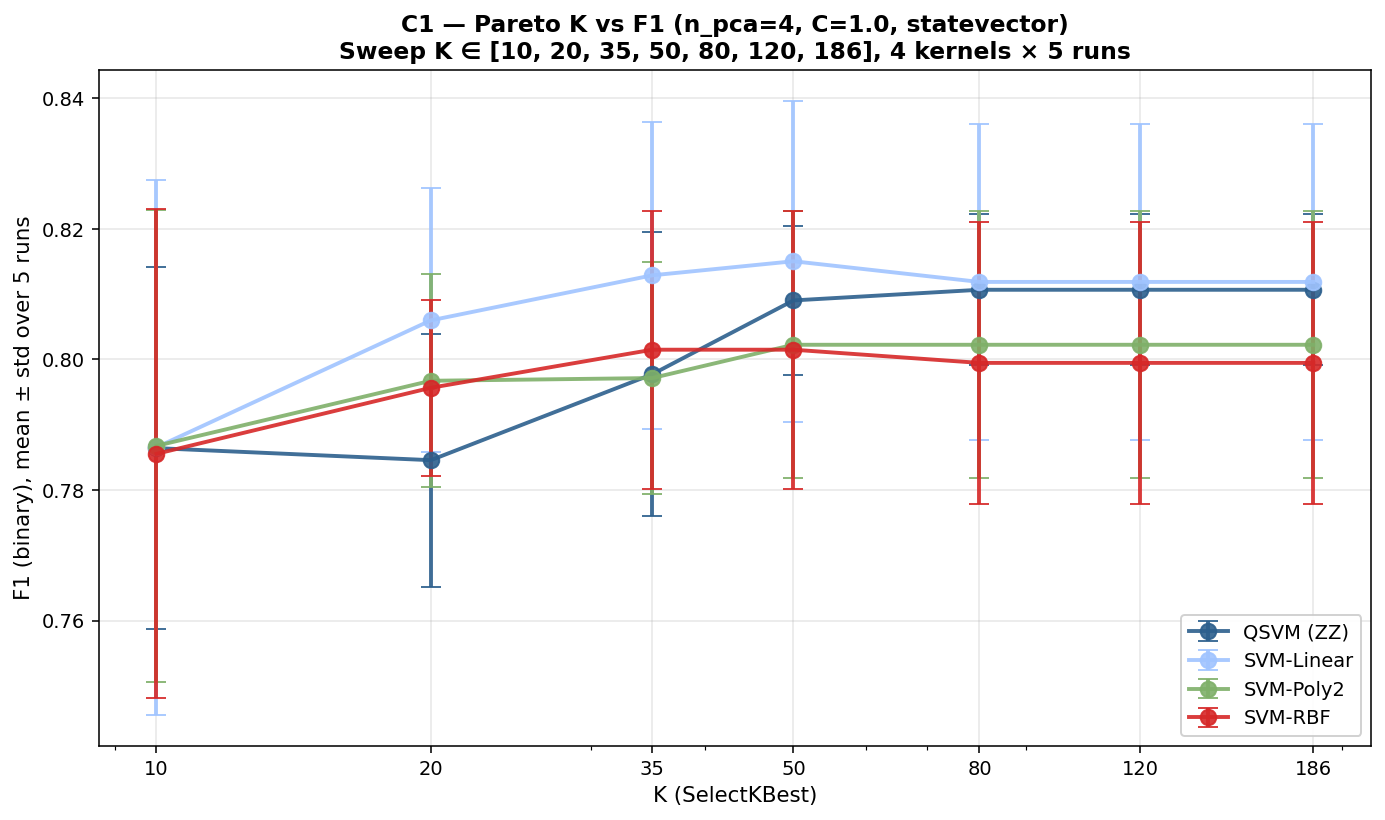

In [9]:
# ── Figure 1: F1 mean±std vs K cho 4 kernels ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for kn in KERNEL_NAMES:
    means, stds = [], []
    for K in K_SWEEP:
        sub = sweep_df[(sweep_df['kernel']==kn) & (sweep_df['K']==K)]
        means.append(float(sub['f1'].mean()))
        stds.append(float(sub['f1'].std()))
    ax.errorbar(K_SWEEP, means, yerr=stds, marker='o', markersize=8,
                linewidth=2, capsize=5, label=DISPLAY_NAMES[kn],
                color=COLORS[kn], alpha=0.9)
ax.set_xlabel('K (SelectKBest)', fontsize=11)
ax.set_ylabel('F1 (binary), mean ± std over 5 runs', fontsize=11)
ax.set_title(f'C1 — Pareto K vs F1 (n_pca={PCA_N}, C={C_NEUTRAL}, statevector)\n'
             f'Sweep K ∈ {K_SWEEP}, 4 kernels × 5 runs',
             fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.set_xticks(K_SWEEP); ax.set_xticklabels([str(k) for k in K_SWEEP])
ax.grid(True, alpha=0.3)
ax.legend(loc='best', framealpha=0.9)
plt.tight_layout()
fig.savefig(f'{REPORTS_DIR}/c1_K_vs_f1.png', dpi=140, bbox_inches='tight')
plt.close(fig)
print(f'Saved: {REPORTS_DIR}/c1_K_vs_f1.png')
display(Image(filename=f'{REPORTS_DIR}/c1_K_vs_f1.png'))


Saved: ../reports_unsw/c1_K_vs_kta.png


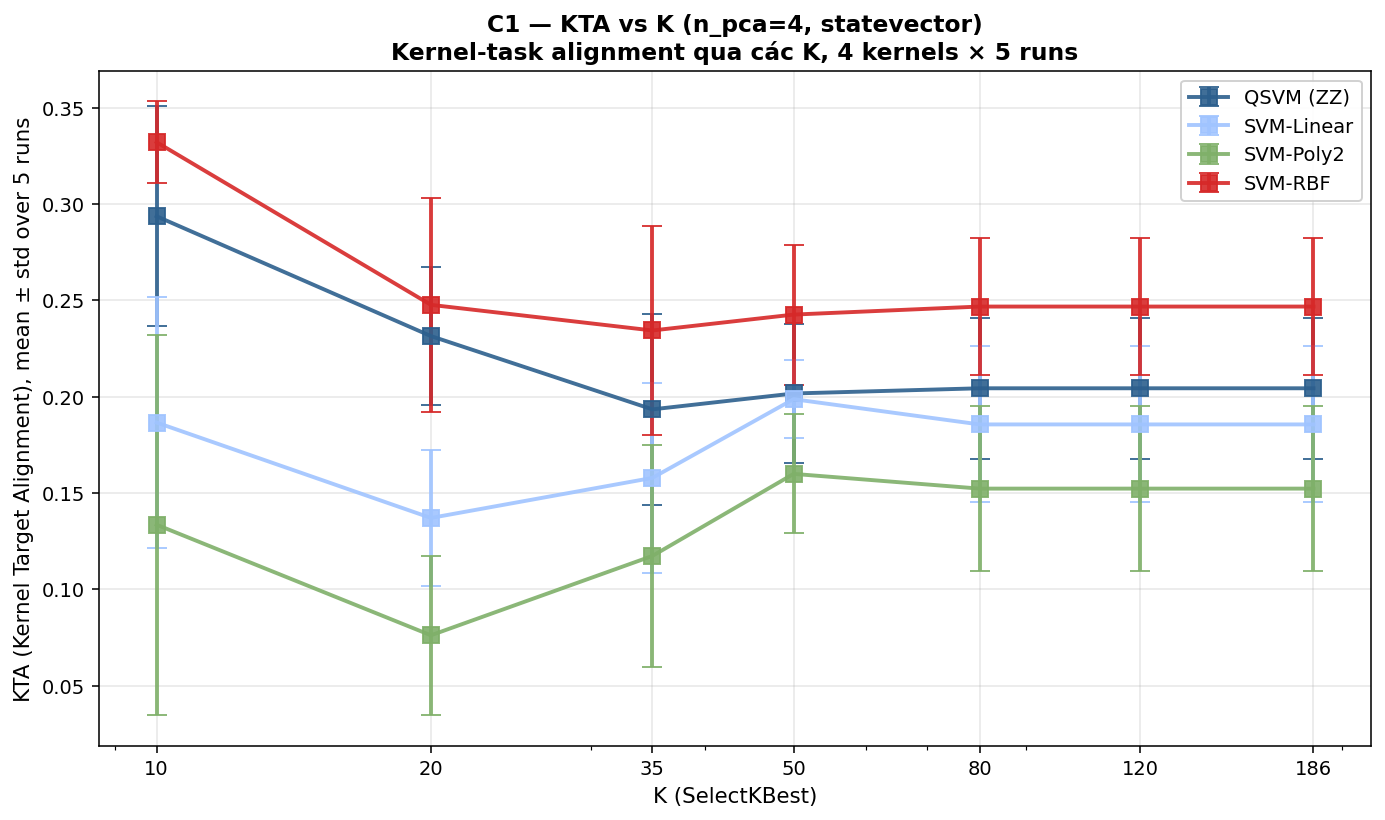

In [10]:
# ── Figure 2: KTA mean±std vs K cho 4 kernels ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for kn in KERNEL_NAMES:
    means, stds = [], []
    for K in K_SWEEP:
        sub = sweep_df[(sweep_df['kernel']==kn) & (sweep_df['K']==K)]
        means.append(float(sub['kta'].mean()))
        stds.append(float(sub['kta'].std()))
    ax.errorbar(K_SWEEP, means, yerr=stds, marker='s', markersize=8,
                linewidth=2, capsize=5, label=DISPLAY_NAMES[kn],
                color=COLORS[kn], alpha=0.9)
ax.set_xlabel('K (SelectKBest)', fontsize=11)
ax.set_ylabel('KTA (Kernel Target Alignment), mean ± std over 5 runs', fontsize=11)
ax.set_title(f'C1 — KTA vs K (n_pca={PCA_N}, statevector)\n'
             f'Kernel-task alignment qua các K, 4 kernels × 5 runs',
             fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.set_xticks(K_SWEEP); ax.set_xticklabels([str(k) for k in K_SWEEP])
ax.grid(True, alpha=0.3)
ax.legend(loc='best', framealpha=0.9)
plt.tight_layout()
fig.savefig(f'{REPORTS_DIR}/c1_K_vs_kta.png', dpi=140, bbox_inches='tight')
plt.close(fig)
print(f'Saved: {REPORTS_DIR}/c1_K_vs_kta.png')
display(Image(filename=f'{REPORTS_DIR}/c1_K_vs_kta.png'))


Saved: ../reports_unsw/c1_K_vs_degeneracy.png


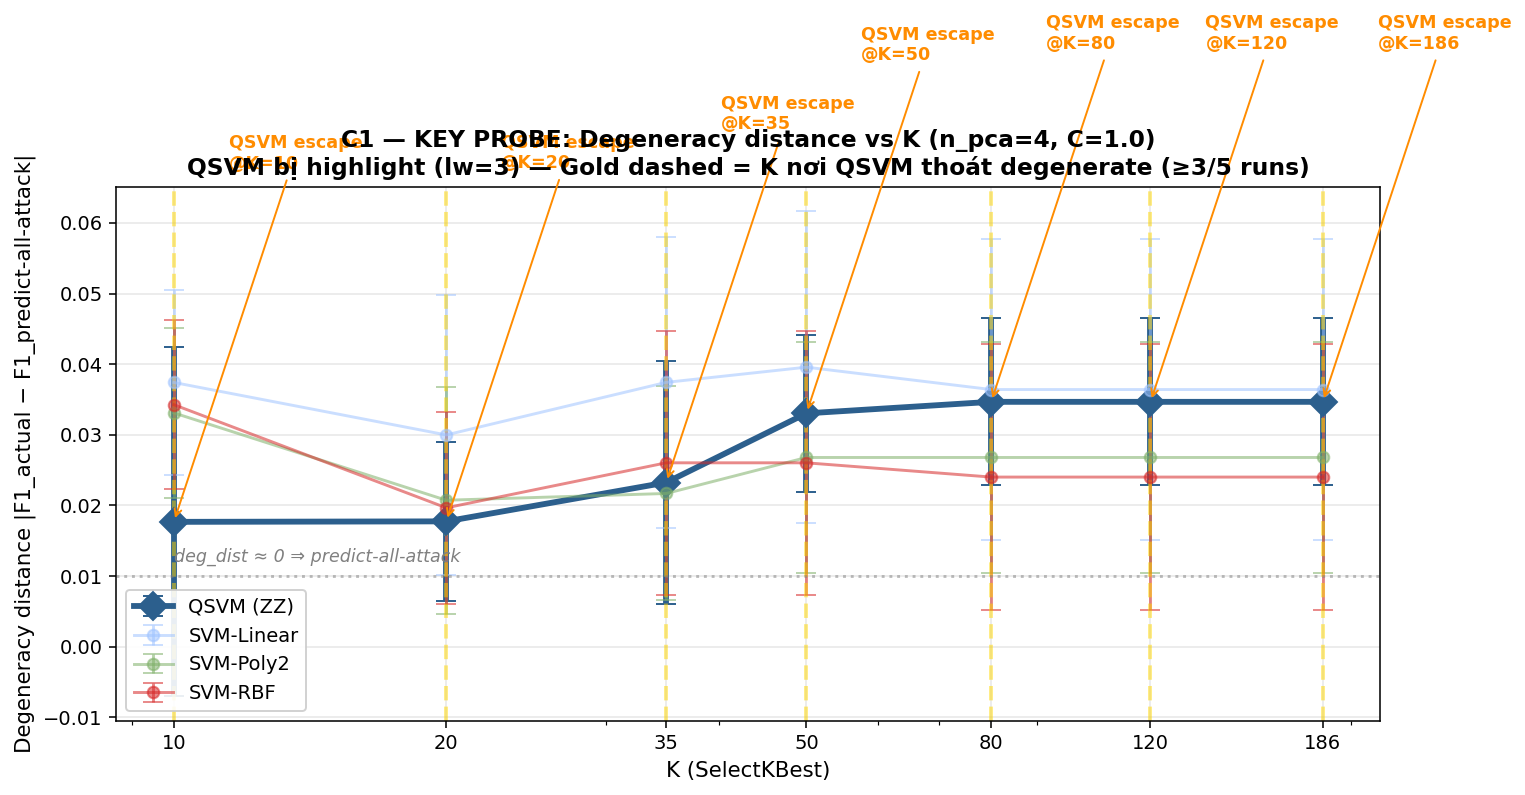

In [11]:
# ── Figure 3 (KEY): Degeneracy distance vs K — QSVM highlight ──────────────
fig, ax = plt.subplots(figsize=(11, 6))
for kn in KERNEL_NAMES:
    means, stds = [], []
    for K in K_SWEEP:
        sub = sweep_df[(sweep_df['kernel']==kn) & (sweep_df['K']==K)]
        means.append(float(sub['degeneracy_distance'].mean()))
        stds.append(float(sub['degeneracy_distance'].std()))
    lw = 3 if kn == 'quantum' else 1.5
    alpha = 1.0 if kn == 'quantum' else 0.55
    ax.errorbar(K_SWEEP, means, yerr=stds, marker='D' if kn=='quantum' else 'o',
                markersize=10 if kn=='quantum' else 6,
                linewidth=lw, capsize=5, label=DISPLAY_NAMES[kn],
                color=COLORS[kn], alpha=alpha)

# Đánh dấu các K mà QSVM thoát degeneracy (n_non_deg >= 3)
for K, f1m, ddm, n_non in escape_candidates:
    ax.axvline(K, color='gold', linestyle='--', alpha=0.5, linewidth=2)
    ax.annotate(f'QSVM escape\n@K={K}',
                xy=(K, ddm), xytext=(K * 1.15, ddm + 0.05),
                fontsize=9, color='darkorange', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='darkorange'))

# Annotation: ngưỡng degeneracy
ax.axhline(0.01, color='gray', linestyle=':', alpha=0.5)
ax.text(K_SWEEP[0], 0.012, 'deg_dist ≈ 0 ⇒ predict-all-attack',
        fontsize=9, color='gray', style='italic')

ax.set_xlabel('K (SelectKBest)', fontsize=11)
ax.set_ylabel('Degeneracy distance |F1_actual − F1_predict-all-attack|', fontsize=11)
ax.set_title(f'C1 — KEY PROBE: Degeneracy distance vs K (n_pca={PCA_N}, C={C_NEUTRAL})\n'
             f'QSVM bị highlight (lw=3) — Gold dashed = K nơi QSVM thoát degenerate (≥3/5 runs)',
             fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.set_xticks(K_SWEEP); ax.set_xticklabels([str(k) for k in K_SWEEP])
ax.grid(True, alpha=0.3)
ax.legend(loc='best', framealpha=0.9)
plt.tight_layout()
fig.savefig(f'{REPORTS_DIR}/c1_K_vs_degeneracy.png', dpi=140, bbox_inches='tight')
plt.close(fig)
print(f'Saved: {REPORTS_DIR}/c1_K_vs_degeneracy.png')
display(Image(filename=f'{REPORTS_DIR}/c1_K_vs_degeneracy.png'))


## 9. Save JSON — `models_unsw/c1_results.json`

In [12]:
# Build k_sweep block với schema chỉ định trong Plan 1.6
k_sweep_block = []
for K in K_SWEEP:
    per_run_list = []
    for rid in RUN_IDS:
        entry = {'run': int(rid)}
        for kn in KERNEL_NAMES:
            row = sweep_df[(sweep_df['K']==K) & (sweep_df['run']==rid) & (sweep_df['kernel']==kn)].iloc[0]
            entry[kn] = {
                'f1':       float(row['f1']),
                'tn':       int(row['tn']),  'fp': int(row['fp']),
                'fn':       int(row['fn']),  'tp': int(row['tp']),
                'kta':      float(row['kta']),
                'is_degenerate':       bool(row['is_degenerate']),
                'degeneracy_distance': float(row['degeneracy_distance']),
                'attack_ratio_test':   float(row['attack_ratio_test']),
                'f1_predict_all_attack': float(row['f1_predict_all_attack']),
            }
        per_run_list.append(entry)

    summary = {}
    for kn in KERNEL_NAMES:
        sub = sweep_df[(sweep_df['K']==K) & (sweep_df['kernel']==kn)]
        summary[kn] = {
            'f1_mean':                 float(sub['f1'].mean()),
            'f1_std':                  float(sub['f1'].std()),
            'kta_mean':                float(sub['kta'].mean()),
            'kta_std':                 float(sub['kta'].std()),
            'n_runs_degenerate':       int(sub['is_degenerate'].sum()),
            'mean_degeneracy_distance':float(sub['degeneracy_distance'].mean()),
        }
    k_sweep_block.append({
        'K': int(K), 'n_pca': int(PCA_N),
        'per_run': per_run_list,
        'summary': summary,
    })

payload = {
    'k_sweep': k_sweep_block,
    'best_qsvm_non_degenerate_config': BEST_QSVM_NON_DEG,
    'metadata': {
        'regime':           'statevector',
        'n_runs':           len(RUN_IDS),
        'K_sweep':          [int(K) for K in K_SWEEP],
        'n_pca_fixed':      int(PCA_N),
        'C_for_all':        float(C_NEUTRAL),
        'C_strategy':       'default_neutral_no_retune',
        'purpose':          'Pareto + escape_degeneracy_probe',
        'config_tag_base':  CONFIG_TAG_BASE,
        'reuse_1_4a_cache_at_K35': True,
        'pipeline': {
            'angle_max': float(ANGLE_MAX),
            'zz_reps':   int(ZZ_REPS),
            'zz_entanglement': ZZ_ENT,
            'n_qubits':  int(N_QUBITS),
        },
        'random_state': RANDOM_STATE,
        'date': datetime.date.today().isoformat(),
    },
}

with open(RESULTS_JSON, 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)
print(f'Saved: {RESULTS_JSON}')
print(f'Size : {os.path.getsize(RESULTS_JSON)} bytes')


Saved: ../models_unsw/c1_results.json
Size : 66884 bytes


## 10. Verdict — 1 dòng kết luận

In [13]:
print('=' * 88)
print('  C1 VERDICT')
print('=' * 88)
if BEST_QSVM_NON_DEG is None:
    print('  ❌ QSVM degenerate trên TOÀN BỘ K ∈', K_SWEEP)
    print('     ⇒ Confirm HONEST NEGATIVE RESULT: ZZFeatureMap 4-qubit không học được')
    print('       boundary có ý nghĩa trên UNSW dù sweep K, n_pca=4 fixed.')
    print('     ⇒ KHÔNG re-run 1.4a/1.5 — kết luận của 1.4a/1.5 (QSVM degenerate) đứng vững.')
else:
    K_best = BEST_QSVM_NON_DEG['K']
    print(f'  ✅ QSVM thoát degeneracy tại K={K_best} '
          f'(F1={BEST_QSVM_NON_DEG["f1_mean"]:.4f}, '
          f'deg_dist={BEST_QSVM_NON_DEG["degeneracy_distance_mean"]:.4f}, '
          f'{BEST_QSVM_NON_DEG["n_runs_non_degenerate"]}/5 runs non-degenerate).')
    print(f'     ⇒ CÓ THỂ re-run 1.4a/1.5 với pipeline (K={K_best}, n_pca={PCA_N}).')
print('=' * 88)
print('DONE.')


  C1 VERDICT
  ✅ QSVM thoát degeneracy tại K=80 (F1=0.8107, deg_dist=0.0347, 5/5 runs non-degenerate).
     ⇒ CÓ THỂ re-run 1.4a/1.5 với pipeline (K=80, n_pca=4).
DONE.
